### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GPT_4_MINI_API_KEY"]=os.getenv("GPT_4_MINI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [5]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.getenv("GPT_4_MINI_API_KEY"),
    base_url="https://models.inference.ai.azure.com"
)

llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b6f445fc1c', 'id': 'chatcmpl-DPhFqFOSw9XdX8Q3yrxxZHHYnCQOK', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d473f-8957-7931-9155-a8b9ead57b44-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 10, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [7]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="<think>\nOkay, the user mentioned they play cricket, so I should start by recognizing that. I need to ask them about their favorite part of the game. Maybe they prefer batting or bowling? It could be a specific moment like hitting a six or taking a wicket. I should also ask about their experience level to get a better idea of what they're interested in. Perhaps they want to discuss techniques or strategies. I should keep it friendly and open-ended to encourage them to share more. Let me phrase it in a way that invites them to talk about their experiences and what they enjoy most.\n</think>\n\nHey Krish! 🏏 That's awesome—cricket is such a thrilling sport! I'd love to hear more about what you enjoy most about playing it. Do you prefer batting, bowling, or fielding? Also, how long have you been playing? I'd be happy to chat about tips, strategies, or even fun cricket moments if you'd like! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens':

### Creating Nodes

In [8]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

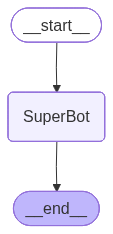

In [9]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Pavan And I like Badminton"},config)

{'messages': [HumanMessage(content='Hi,My name is Pavan And I like Badminton', additional_kwargs={}, response_metadata={}, id='0b2d801d-c63e-4d70-9d31-397b64a6c967'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Pavan and mentioned he likes badminton. I need to respond in a friendly and engaging way. Let me start by acknowledging his name and interest. Maybe ask him about his experience with badminton—how long he's been playing, his favorite part, or if he competes. Also, offer help if he has questions or wants to discuss strategies. Keep it open-ended to encourage conversation. Let me check for any typos or errors. Alright, that should work.\n</think>\n\nHi Pavan! 👋 Nice to meet you! Badminton sounds like an awesome hobby—super fun and great for fitness! Do you play it casually with friends, or are you into competitive matches? I'd love to hear more about what you enjoy most about the game! 🎾", additional_kwargs={}, response_metadata={'token_usage': {'completion_

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

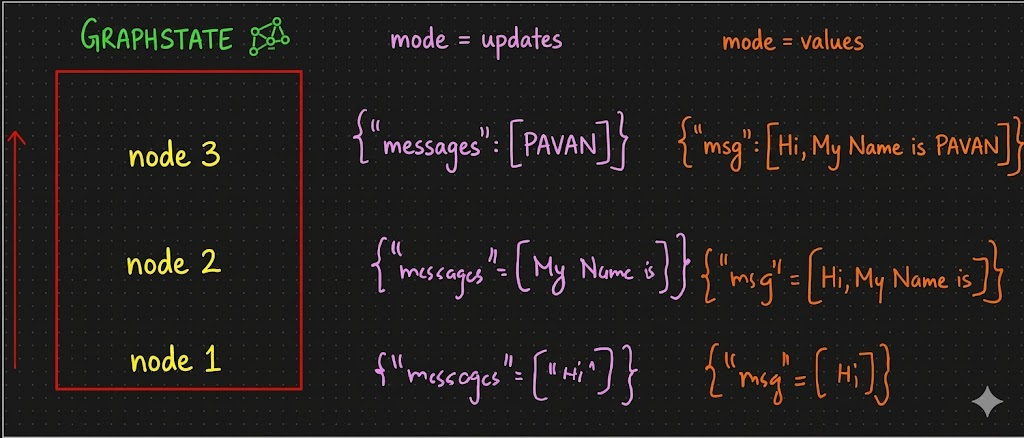

#### Streaming The Responses With Stream Method

In [11]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Pavan And I like badminton"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Pavan and he's into badminton. Let me start by acknowledging his introduction. I should respond warmly to make him feel welcome. Since he mentioned badminton, I can ask about his experience level or what he enjoys most about the sport. Maybe he's looking for tips, or just wants to chat. I should keep the conversation open-ended and friendly. Let me make sure my response is positive and shows genuine interest in his hobby. Also, check if there's anything specific he wants to discuss related to badminton. Avoid making assumptions, just invite him to share more. Alright, time to put that into a friendly message.\n</think>\n\nHello Pavan! 👋 Welcome! It's great to meet you. I love that you're into badminton - it's such an exciting and dynamic sport! 🏸 \n\nWould you like to share a bit more about what you enjoy most about playing? Are you more into singles or doubles? I'd love to hear about your experiences or even lear

In [12]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Pavan And I like badminton', additional_kwargs={}, response_metadata={}, id='e87c2c95-037d-4746-86fd-ad52c7da7b33'), AIMessage(content="<think>\nOkay, the user is Pavan and he's into badminton. Let me start by acknowledging his introduction. I should respond warmly to make him feel welcome. Since he mentioned badminton, I can ask about his experience level or what he enjoys most about the sport. Maybe he's looking for tips, or just wants to chat. I should keep the conversation open-ended and friendly. Let me make sure my response is positive and shows genuine interest in his hobby. Also, check if there's anything specific he wants to discuss related to badminton. Avoid making assumptions, just invite him to share more. Alright, time to put that into a friendly message.\n</think>\n\nHello Pavan! 👋 Welcome! It's great to meet you. I love that you're into badminton - it's such an exciting and dynamic sport! 🏸 \n\nWould you like to share a 

In [13]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, the user mentioned liking both badminton and football again. They might be emphasizing their interest in both sports. I need to acknowledge their repetition and maybe ask a new question to keep the conversation flowing.\n\nSince they already talked about badminton and football before, perhaps I should ask for more details about their football preferences. Maybe their favorite team, position they play, or how they balance both sports. Also, check if they have any specific goals in either sport. I should keep the tone friendly and enthusiastic to encourage more sharing. Let me make sure the response is engaging and opens up new topics for discussion.\n</think>\n\nHi Pavan! 😊 I love how you’re passionate about both sports! Let me ask—when you play football, do you prefer a specific role (like striker, midfielder, or defender), or do you enjoy how the game changes depending on the position? And do you find that your badminton agi

In [14]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Pavan And I like badminton', additional_kwargs={}, response_metadata={}, id='e87c2c95-037d-4746-86fd-ad52c7da7b33'), AIMessage(content="<think>\nOkay, the user is Pavan and he's into badminton. Let me start by acknowledging his introduction. I should respond warmly to make him feel welcome. Since he mentioned badminton, I can ask about his experience level or what he enjoys most about the sport. Maybe he's looking for tips, or just wants to chat. I should keep the conversation open-ended and friendly. Let me make sure my response is positive and shows genuine interest in his hobby. Also, check if there's anything specific he wants to discuss related to badminton. Avoid making assumptions, just invite him to share more. Alright, time to put that into a friendly message.\n</think>\n\nHello Pavan! 👋 Welcome! It's great to meet you. I love that you're into badminton - it's such an exciting and dynamic sport! 🏸 \n\nWould you like to share a 

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Contains langgraph_node, the node emitting the event.

In [15]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Pavan and I like to play badminton"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Pavan and I like to play badminton']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d4751-4d18-7223-bf7e-1fe5c8a7110c', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Pavan And I like badminton', additional_kwargs={}, response_metadata={}, id='e87c2c95-037d-4746-86fd-ad52c7da7b33'), AIMessage(content="<think>\nOkay, the user is Pavan and he's into badminton. Let me start by acknowledging his introduction. I should respond warmly to make him feel welcome. Since he mentioned badminton, I can ask about his experience level or what he enjoys most about the sport. Maybe he's looking for tips, or just wants to chat. I should keep the conversation open-ended and friendly. Let me make sure my response is positive and shows genuine interest in his hobby. Also, check if there's anything specific he wants to discuss relate